# Fig 9: Effects of a Marginal Emission of CO2

the impact pathway from a 1 GtC pulse:
- **A**: Fossil CO2 emissions (the pulse)
- **B**: Change in atmospheric CO2 concentrations
- **C**: Change in global mean surface temperature
- **D**: Present value of labor damages

In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [9]:
# =============================================================================
# CONFIGURATION
# =============================================================================

PULSE_YEAR = 2025
DISCOUNT_RATE = 0.02  # 2%
RCP = 'rcp85'
SSP = 'SSP3'  # Use SSP3 to match Table 5 reference values
PULSE_AMT = 1.0  # GtC

# Conversion factors
GTC_TO_GTCO2 = 44.0098 / 12.011  # ~3.664
GTC_TO_TCO2 = 3.67e9

# Year range for plots
PLOT_START_YEAR = 2000
PLOT_END_YEAR = 2300

# Paths
BASE_DIR = Path('/project/cil/home_dirs/scadavidsanchez/projects/dscim-labor-2025-update2026')
OUTPUT_DIR = BASE_DIR / 'paper-updates'

# FAIR data paths
# Panel B:  new FAIR concentration file with full carbon-climate coupling
FAIR_CONC_PATH = OUTPUT_DIR / 'fair_co2_concentrations_rcp85_pulse2020_2025.nc'
# Panels C & D: Use existing temperature file from pipeline
FAIR_TEMP_PATH = Path('/project/cil/gcp/integration/gmst_94k_2025p.nc4')

# Damage function coefficients (OLS - for median line)
DAMAGE_COEF_PATH = BASE_DIR / f'results/scc_output/AR6_ssp/labor/{PULSE_YEAR}/unmasked/adding_up_constant_model_collapsed_eta2.0_rho0.0_damage_function_coefficients.nc4'

# Damage function fit with quantile regression (for full uncertainty IQR)
# This file has 19 quantiles (0.05 to 0.95) to capture damage function uncertainty
DAMAGE_FIT_PATH = BASE_DIR / f'results/scc_output_full_uncertainty/AR6_ssp/labor/{PULSE_YEAR}/unmasked/adding_up_constant_model_collapsed_eta2.0_rho0.0_damage_function_fit.nc4'

print(f"Pulse year: {PULSE_YEAR}")
print(f"Discount rate: {DISCOUNT_RATE*100:.0f}%")
print(f"Scenario: {SSP} / {RCP.upper()}")

Pulse year: 2025
Discount rate: 2%
Scenario: SSP3 / RCP85


## Load Data

In [10]:
# Load FAIR temperature data (for Panels C and D)
print("Loading FAIR temperature data...")
ds_fair_temp = xr.open_dataset(FAIR_TEMP_PATH)

# Helper function to find index for coordinate value
def get_coord_idx(ds, dim, value):
    """Get integer index for a coordinate value."""
    coords = ds[dim].values
    idx = np.where(coords == value)[0]
    if len(idx) == 0:
        raise ValueError(f"Value '{value}' not found in dimension '{dim}'. Available: {coords}")
    return int(idx[0])

# indices for gas and rcp
gas_idx = get_coord_idx(ds_fair_temp, 'gas', 'CO2_Fossil')
rcp_idx = get_coord_idx(ds_fair_temp, 'rcp', RCP)

# Get temperature data for all simulations using isel
control_temp = ds_fair_temp['control_temperature'].isel(gas=gas_idx, rcp=rcp_idx)
pulse_temp = ds_fair_temp['pulse_temperature'].isel(gas=gas_idx, rcp=rcp_idx)
delta_temp = pulse_temp - control_temp
years_fair = ds_fair_temp['year'].values
n_sims_temp = len(ds_fair_temp.simulation)

# et medianparams for point estimate
control_temp_median = ds_fair_temp['medianparams_control_temperature'].isel(gas=gas_idx, rcp=rcp_idx).values
pulse_temp_median = ds_fair_temp['medianparams_pulse_temperature'].isel(gas=gas_idx, rcp=rcp_idx).values
delta_temp_median = pulse_temp_median - control_temp_median

print(f"  Temperature simulations: {n_sims_temp:,}")

# =============================================================================
# Load FAIR concentration data (for Panel B)
# =============================================================================
print("Loading FAIR concentration data...")
try:
    ds_fair_conc = xr.open_dataset(FAIR_CONC_PATH)
    USE_FAIR_CONC = True

    # Get concentration data - use .isel() with index lookup to avoid method='nearest' issues
    control_conc = ds_fair_conc['control_co2_concentration']
    
    # Find the pulse year index explicitly
    pulse_years_avail = ds_fair_conc['pulse_year'].values
    if PULSE_YEAR in pulse_years_avail:
        pulse_year_idx = int(np.where(pulse_years_avail == PULSE_YEAR)[0][0])
        pulse_conc = ds_fair_conc['pulse_co2_concentration'].isel(pulse_year=pulse_year_idx)
    else:
        raise ValueError(f"Pulse year {PULSE_YEAR} not in available pulse years: {pulse_years_avail}")
    
    delta_conc = pulse_conc - control_conc
    years_conc = ds_fair_conc['year'].values
    n_sims_conc = len(ds_fair_conc.simulation)

    # Median params - same approach
    control_conc_median = ds_fair_conc['medianparams_control_co2_concentration'].values
    pulse_conc_median = ds_fair_conc['medianparams_pulse_co2_concentration'].isel(pulse_year=pulse_year_idx).values
    delta_conc_median = pulse_conc_median - control_conc_median

    print(f"  Concentration simulations: {n_sims_conc:,}")
    print(f"  Using FAIR concentrations with full carbon-climate coupling")

except FileNotFoundError:
    USE_FAIR_CONC = False
    print(f"  WARNING: FAIR concentration file not found: {FAIR_CONC_PATH}")
    print(f"  Falling back to Joos IRF approximation (does NOT capture secondary CO2 rise)")

# Load damage function coefficients (OLS - for median line)
print("Loading damage function coefficients (OLS)...")
ds_coef = xr.open_dataset(DAMAGE_COEF_PATH)

# Get SSP index
ssp_idx = get_coord_idx(ds_coef, 'ssp', SSP)

psi1 = ds_coef['anomaly'].isel(ssp=ssp_idx).squeeze().values
psi2 = ds_coef['np.power(anomaly, 2)'].isel(ssp=ssp_idx).squeeze().values
years_coef = ds_coef['year'].values

print(f"  Coefficient years: {years_coef[0]} - {years_coef[-1]}")

# 
#  damage function fit with quantile regression (for full uncertainty IQR)
print("Loading damage function quantile fit...")
ds_damage_fit = xr.open_dataset(DAMAGE_FIT_PATH)

# Get dimensions
quantiles = ds_damage_fit['q'].values
anomaly_grid = ds_damage_fit['anomaly'].values
years_fit = ds_damage_fit['year'].values
n_quantiles = len(quantiles)

# y_hat for our SSP - shape: (discount_type, ssp, model, anomaly, q, year)
ssp_fit_idx = get_coord_idx(ds_damage_fit, 'ssp', SSP)
y_hat = ds_damage_fit['y_hat'].isel(ssp=ssp_fit_idx, discount_type=0, model=0).values  # shape: (anomaly, q, year)

print(f"  Quantiles: {quantiles}")
print(f"  Anomaly grid: {anomaly_grid.min():.1f} to {anomaly_grid.max():.1f} °C ({len(anomaly_grid)} points)")
print(f"  Years: {years_fit[0]} - {years_fit[-1]}")

Loading FAIR temperature data...
  Temperature simulations: 94,378
Loading FAIR concentration data...
  Concentration simulations: 2,237
  Using FAIR concentrations with full carbon-climate coupling
Loading damage function coefficients (OLS)...
  Coefficient years: 2025 - 2300
Loading damage function quantile fit...
  Quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
  Anomaly grid: 0.0 to 19.8 °C (100 points)
  Years: 2025 - 2300


## Compute Panel Data

In [11]:
# Panel B: CO2 concentration change
if USE_FAIR_CONC:
    # Use FAIR concentrations with full carbon-climate coupling
    year_mask_conc = (years_conc >= PLOT_START_YEAR) & (years_conc <= PLOT_END_YEAR)
    years_plot_conc = years_conc[year_mask_conc]

    delta_C = delta_conc.values[:, year_mask_conc]
    dC_median = np.median(delta_C, axis=0)
    dC_q25 = np.percentile(delta_C, 25, axis=0)
    dC_q75 = np.percentile(delta_C, 75, axis=0)

    # Also compute from medianparams for reference
    dC_medianparams = delta_conc_median[year_mask_conc]

    print("Panel B (CO2)  Using FAIR with carbon-climate coupling:")
    print(f"  Peak median: {np.max(dC_median):.4f} ppm")
    print(f"  Peak medianparams: {np.max(dC_medianparams):.4f} ppm")

    # Check for secondary rise
    idx_2100 = np.where(years_plot_conc == 2100)[0][0]
    idx_2200 = np.where(years_plot_conc == 2200)[0][0]
    print(f"  dC at 2100: {dC_median[idx_2100]:.4f} ppm")
    print(f"  dC at 2200: {dC_median[idx_2200]:.4f} ppm")
    if dC_median[idx_2200] > dC_median[idx_2100]:
        print(f"  Secondary rise detected!")

else:
    # fallback: Use Joos IRF (doesn't capture secondary rise)
    def compute_co2_irf(years, pulse_year, pulse_gtc=1.0):
        """CO2 impulse response function (Joos et al. 2013)"""
        a0, a1, a2, a3 = 0.2173, 0.2240, 0.2824, 0.2763
        tau1, tau2, tau3 = 394.4, 36.54, 4.304
        PPM_PER_GTC = 1.0 / 2.124

        t = np.maximum(years - pulse_year, 0)
        irf = a0 + a1 * np.exp(-t / tau1) + a2 * np.exp(-t / tau2) + a3 * np.exp(-t / tau3)
        irf[years < pulse_year] = 0
        return pulse_gtc * PPM_PER_GTC * irf

    years_plot_conc = years_fair[(years_fair >= PLOT_START_YEAR) & (years_fair <= PLOT_END_YEAR)]
    dC_median = compute_co2_irf(years_plot_conc, PULSE_YEAR, PULSE_AMT)

    # Scale IQR by temperature uncertainty ratio (approximation)
    year_mask_temp = (years_fair >= PLOT_START_YEAR) & (years_fair <= PLOT_END_YEAR)
    delta_T_plot = delta_temp.values[:, year_mask_temp]
    dT_med_plot = np.median(delta_T_plot, axis=0)
    dT_q25_plot = np.percentile(delta_T_plot, 25, axis=0)
    dT_q75_plot = np.percentile(delta_T_plot, 75, axis=0)

    iqr_ratio = np.where(dT_med_plot > 1e-8, (dT_q75_plot - dT_q25_plot) / dT_med_plot, 0)
    iqr_ratio = np.clip(iqr_ratio, 0, 2)
    dC_q25 = dC_median * (1 - 0.5 * iqr_ratio)
    dC_q75 = dC_median * (1 + 0.5 * iqr_ratio)

    print("Panel B (CO2) - Using Joos IRF (fallback):")
    print(f"  WARNING: Does NOT capture secondary CO2 rise from ocean warming")
    print(f"  Peak: {np.max(dC_median):.4f} ppm")


# Panel C: Temperature change (from all simulations)
year_mask_temp = (years_fair >= PLOT_START_YEAR) & (years_fair <= PLOT_END_YEAR)
years_plot_temp = years_fair[year_mask_temp]

delta_T = delta_temp.values[:, year_mask_temp]
dT_median = np.median(delta_T, axis=0)
dT_q25 = np.percentile(delta_T, 25, axis=0)
dT_q75 = np.percentile(delta_T, 75, axis=0)

print("\nPanel C (Temperature):")
print(f"  Peak median dT: {np.max(dT_median)*1000:.3f} mK ({np.max(dT_median):.6f} °C)")

Panel B (CO2)  Using FAIR with carbon-climate coupling:
  Peak median: 0.4697 ppm
  Peak medianparams: 0.4698 ppm
  dC at 2100: 0.3341 ppm
  dC at 2200: 0.3993 ppm
  Secondary rise detected!

Panel C (Temperature):
  Peak median dT: 1.500 mK (0.001500 °C)


In [12]:
# Panel D: Discounted marginal damages with FULL uncertainty
# 
# The IQR should reflect BOTH:
#   1. climate sensitivity uncertainty (94k FAIR simulations)
#   2. damage function uncertainty (19 quantile regressions)
#
#   - For each year, interpolate the quantile damage function fit (y_hat) to get
#     damages at each temperature anomaly for each quantile
#   - For each FAIR simulation, get the base temperature and compute marginal damages
#     by taking the derivative of the damage function at that temperature
#   - This gives us N_sims × N_quantiles damage trajects
#   - raw percentiles 
# =============================================================================

from scipy.interpolate import interp1d

years_damage = years_coef[years_coef >= PULSE_YEAR]
n_years_damage = len(years_damage)

print("Building damage function interpolators for each quantile...")

# Get year indices mapping
year_to_fit_idx = {yr: i for i, yr in enumerate(years_fit)}

# Sample from simulations to avoid memory issues
N_SAMPLE_SIMS = 5000  # Sample from 94k simulations
np.random.seed(42)
sample_sim_indices = np.random.choice(n_sims_temp, size=min(N_SAMPLE_SIMS, n_sims_temp), replace=False)

# Full distribution: N_sample_sims × N_quantiles × N_years
n_sample = len(sample_sim_indices)
discounted_damages_full = np.zeros((n_sample, n_quantiles, n_years_damage))

print(f"Computing discounted damages for {n_sample} simulations × {n_quantiles} quantiles...")

for i, yr in enumerate(years_damage):
    fair_idx = np.where(years_fair == yr)[0]
    if len(fair_idx) == 0:
        continue
    fair_idx = fair_idx[0]
    
    fit_idx = year_to_fit_idx.get(yr)
    if fit_idx is None:
        continue

    # Discount factor
    t = yr - PULSE_YEAR
    df = 1.0 / ((1 + DISCOUNT_RATE) ** t)

    # Get base temperatures for sampled simulations
    T_base_sample = control_temp.values[sample_sim_indices, fair_idx]
    dT_sample = delta_temp.values[sample_sim_indices, fair_idx]

    # Get damage function values for this year: shape (anomaly, q)
    damages_by_anomaly = y_hat[:, :, fit_idx]  # shape: (100, 19)

    # For each quantile, interpolate to get marginal damages at each base temperature
    for q_idx in range(n_quantiles):
        # Interpolate damages as function of anomaly
        damages_q = damages_by_anomaly[:, q_idx]
        interp_func = interp1d(anomaly_grid, damages_q, kind='linear', 
                               bounds_error=False, fill_value='extrapolate')
        
        # Compute damages at T_base and T_base + epsilon to get derivative
        eps = 0.01  # Small temperature increment for numerical derivative
        D_base = interp_func(T_base_sample)
        D_plus = interp_func(T_base_sample + eps)
        marginal_per_C = (D_plus - D_base) / eps  # $/°C
        
        # Marginal damage from 1 tCO2 = marginal_per_C * dT / (GtC to tCO2)
        md_tco2 = (marginal_per_C * dT_sample) / GTC_TO_TCO2
        
        # Apply discount factor
        discounted_damages_full[:, q_idx, i] = md_tco2 * df

# flatten to get full joint distribution: (n_sample × n_quantiles, n_years)
discounted_damages_flat = discounted_damages_full.reshape(-1, n_years_damage)

#  RAW percentiles 
dd_median = np.percentile(discounted_damages_flat, 50, axis=0)
dd_q25 = np.percentile(discounted_damages_flat, 25, axis=0)
dd_q75 = np.percentile(discounted_damages_flat, 75, axis=0)

# mean for reference
dd_mean = np.mean(discounted_damages_flat, axis=0)

# SCC from different distributions
scc_median = np.sum(dd_median)
scc_mean = np.sum(dd_mean)
scc_full_q25 = np.percentile(np.sum(discounted_damages_flat, axis=1), 25)
scc_full_q75 = np.percentile(np.sum(discounted_damages_flat, axis=1), 75)

# Peak info
peak_idx = np.argmax(dd_median)

print(f"\nPanel D (Discounted Damages) - FULL UNCERTAINTY (RAW):")
print(f"  Sampled simulations: {n_sample:,}")
print(f"  Damage function quantiles: {n_quantiles}")
print(f"  Total trajectories: {n_sample * n_quantiles:,}")
print(f"  Post-processing: NONE (raw values)")
print(f"\n  Peak (median): ${dd_median[peak_idx]:.4f}/tCO2 at year {years_damage[peak_idx]}")
print(f"  SCC (median): ${scc_median:.2f}/tCO2")
print(f"  SCC (mean): ${scc_mean:.2f}/tCO2")
print(f"  SCC IQR (full dist): ${scc_full_q25:.2f} - ${scc_full_q75:.2f}/tCO2")
print(f"\n  Min values: median={dd_median.min():.4f}, q25={dd_q25.min():.4f}, q75={dd_q75.min():.4f}")
print(f"  (Table 5 reference for {SSP} {RCP.upper()} 2%: ~$16.7/tCO2)")

Building damage function interpolators for each quantile...
Computing discounted damages for 5000 simulations × 19 quantiles...

Panel D (Discounted Damages) - FULL UNCERTAINTY (RAW):
  Sampled simulations: 5,000
  Damage function quantiles: 19
  Total trajectories: 95,000
  Post-processing: NONE (raw values)

  Peak (median): $0.1179/tCO2 at year 2059
  SCC (median): $13.88/tCO2
  SCC (mean): $22.48/tCO2
  SCC IQR (full dist): $6.95 - $28.07/tCO2

  Min values: median=-0.0589, q25=-0.1376, q75=-0.0296
  (Table 5 reference for SSP3 RCP85 2%: ~$16.7/tCO2)


## Create Figure

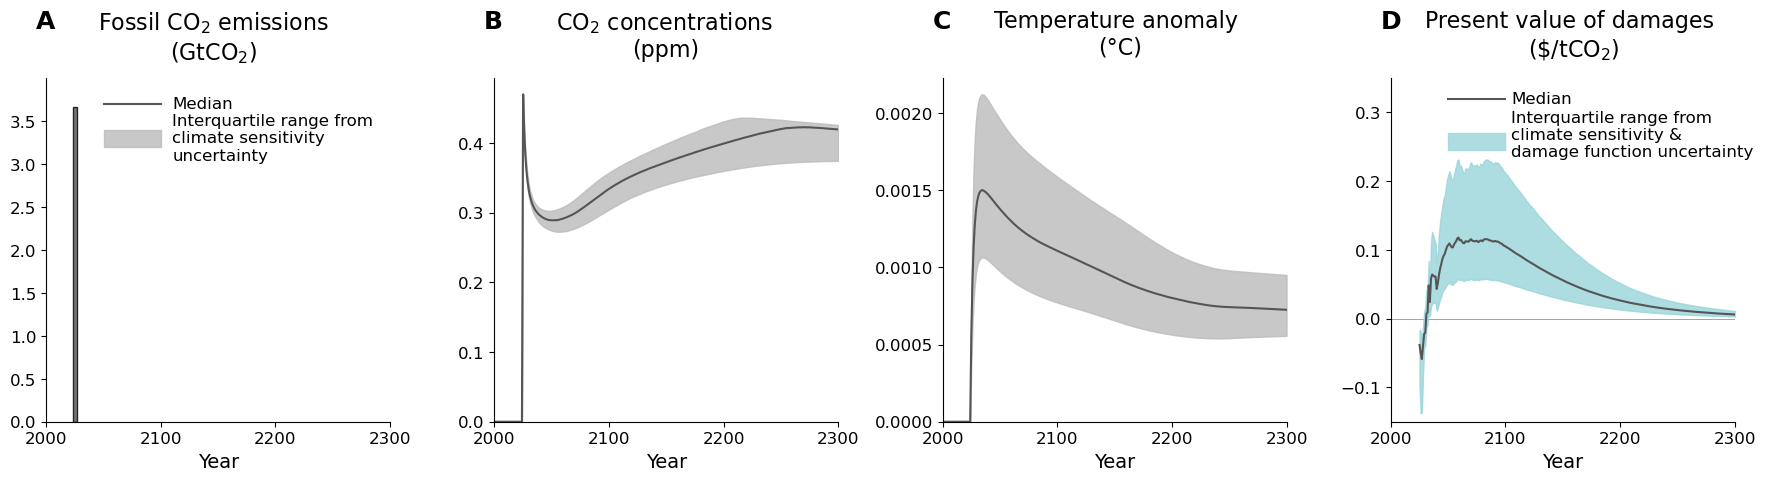

In [13]:
def plot_figure9(save=True):
    """
    Create Figure 9 matching the paper's style.
    1x4 layout, gray shading for B/C (climate uncertainty), blue shading for D (climate + damage fn uncertainty).
    """
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=12)

    # Colors
    gray_color = '#555555'
    blue_color = '#3182bd'
    gray_shading = '#BBBBBB'
    blue_shading = '#99D5DA'

    # Panel A: CO2 pulse only 
    # contains legend for gray Panels B/C only
    ax = axes[0]

    pulse_gtco2 = PULSE_AMT * GTC_TO_GTCO2
    ax.bar(PULSE_YEAR, pulse_gtco2, width=4, color=gray_color, alpha=0.8, edgecolor='black')

    ax.set_xlabel('Year', fontsize=14)
    # ax.set_ylabel('Fossil CO$_2$ emissions (GtCO$_2$)', fontsize=14)
    ax.set_xlim(PLOT_START_YEAR, PLOT_END_YEAR)
    ax.set_xticks(np.arange(PLOT_START_YEAR, PLOT_END_YEAR + 1, 100))
    ax.set_ylim(0, 4)
    ax.set_yticks(np.arange(0, 3.6, 0.5))

    # Legend in Panel A for gray Panels B & C only
    ax.plot([2050, 2100], [3.7, 3.7], color=gray_color, linewidth=1.5)
    ax.text(2110, 3.7, 'Median', fontsize=12, va='center')
    ax.fill_between([2050, 2100], [3.2, 3.2], [3.4, 3.4], color=gray_shading, alpha=0.8)
    ax.text(2110, 3.3, 'Interquartile range from \nclimate sensitivity \nuncertainty', fontsize=12, va='center')

    # Panel label
    ax.text(-0.03, 1.2, 'A', transform=ax.transAxes, fontsize=18, fontweight='bold',
            va='top', ha='left')
    ax.text(0.15, 1.2, 'Fossil CO$_2$ emissions \n(GtCO$_2$)', transform=ax.transAxes, fontsize=16,
            va='top', ha='left', multialignment='center')

    # =========================================================================
    # Panel B: CO2 concentration change (gray for climate uncertainty)
    # Uses FAIR concentrations with full carbon-climate coupling
    # =========================================================================
    ax = axes[1]

    ax.fill_between(years_plot_conc, dC_q25, dC_q75, color=gray_shading, alpha=0.8)
    ax.plot(years_plot_conc, dC_median, color=gray_color, linewidth=1.5)

    ax.set_xlabel('Year', fontsize=14)
    # ax.set_ylabel('CO$_2$ concentrations (ppm)', fontsize=11)
    ax.set_xlim(PLOT_START_YEAR, PLOT_END_YEAR)
    ax.set_xticks(np.arange(PLOT_START_YEAR, PLOT_END_YEAR + 1, 100))
    ax.set_ylim(0, None)

    ax.text(-0.03, 1.2, 'B', transform=ax.transAxes, fontsize=18, fontweight='bold',
            va='top', ha='left')
    ax.text(0.18, 1.2, 'CO$_2$ concentrations \n(ppm)', transform=ax.transAxes, fontsize=16,
            va='top', ha='left', multialignment='center')

    # =========================================================================
    # Panel C: Temperature change (gray for climate uncertainty)
    # =========================================================================
    ax = axes[2]

    # Keep in degrees C (do NOT convert to mK)
    ax.fill_between(years_plot_temp, dT_q25, dT_q75, color=gray_shading, alpha=0.8)
    ax.plot(years_plot_temp, dT_median, color=gray_color, linewidth=1.5)

    ax.set_xlabel('Year', fontsize=14)
    # ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)
    ax.set_xlim(PLOT_START_YEAR, PLOT_END_YEAR)
    ax.set_xticks(np.arange(PLOT_START_YEAR, PLOT_END_YEAR + 1, 100))
    ax.set_ylim(0, None)
    ax.set_yticks(np.arange(0, 0.0021, 0.0005))

    ax.text(-0.03, 1.2, 'C', transform=ax.transAxes, fontsize=18, fontweight='bold',
            va='top', ha='left')
    ax.text(0.15, 1.2, 'Temperature anomaly \n(°C)', transform=ax.transAxes, fontsize=16,
            va='top', ha='left', multialignment='center')

    # Panel D: Discounted damages (blue for combined uncertainty)
    # Has its own legend in upper right
    ax = axes[3]

    ax.fill_between(years_damage, dd_q25, dd_q75, color=blue_shading, alpha=0.8)
    ax.plot(years_damage, dd_median, color=gray_color, linewidth=1.5)

    ax.set_xlabel('Year', fontsize=14)
    # ax.set_ylabel('Present value of damages ($/tCO$_2$)', fontsize=11)
    ax.set_xlim(PLOT_START_YEAR, PLOT_END_YEAR)
    ax.set_xticks(np.arange(PLOT_START_YEAR, PLOT_END_YEAR + 1, 100))
    # No ylim constraint - but ylim added to make space for legend
    ax.set_ylim(-0.15, 0.35)
    ax.set_yticks(np.arange(-0.1, 0.31, 0.1))

    # Panel D legend in upper right
    ax.plot([2050, 2100], [0.32, 0.32], 
            color=gray_color, linewidth=1.5)
    ax.text(2105, 0.32, 'Median', fontsize=12, va='center')
    
    # iqr_y_top = dd_q75.max() * 0.85
    # iqr_y_bot = dd_q75.max() * 0.7
    ax.fill_between([2050, 2100], [0.245, 0.245], [0.27, 0.27], 
                    color=blue_shading, alpha=0.8)
    ax.text(2105, 0.2675, 'Interquartile range from \nclimate sensitivity & \ndamage function uncertainty', 
            fontsize=12, va='center')

    ax.text(-0.03, 1.2, 'D', transform=ax.transAxes, fontsize=18, fontweight='bold',
            va='top', ha='left')
    ax.text(0.1, 1.2, 'Present value of damages \n(\$/tCO$_2$)', transform=ax.transAxes, fontsize=16,
            va='top', ha='left', multialignment='center')

    # =========================================================================
    # Add horizontal line at y=0 to ALL panels
    # =========================================================================
    for ax in axes:
        ax.axhline(0, color='gray', linewidth=0.5, zorder=0)

    # =========================================================================
    # Final adjustments
    # =========================================================================
    plt.tight_layout()

    if save:
        pdf_path = OUTPUT_DIR / f'figure9_pulse{PULSE_YEAR}.pdf'
        png_path = OUTPUT_DIR / f'figure9_pulse{PULSE_YEAR}.png'
        fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {pdf_path}")
        print(f"Saved: {png_path}")

    plt.show()
    return fig

fig = plot_figure9(save=False)